# NEIU Rooftop Ozone Study

Ozone forms when sunlight photolyzes nitrogen dioxide (NO₂) in the presence
of volatile organic compounds. This notebook examines ozone and NO₂ from the
rooftop **QuantAQ MODULAIR** at Northeastern Illinois University (NEIU),
paired with wind, temperature, and solar radiation from the co-located
**NEIU (Ambient Weather) station**.

It is a rooftop analogue of the Cook County AQS ozone study, reusing the same
AQI heatmap and wind-rose machinery so the two are directly comparable. The
key structural advantage here: the pollutant sensor and the weather station
share a rooftop, so — unlike the AQS/O'Hare pairing — there is **no spatial
displacement** between wind and concentration.

**Instrument caveats when comparing to the AQS notebook.** QuantAQ reports
O₃ and NO₂ from **electrochemical** cells in **ppb** (AQS uses UV-absorption
ozone in ppm and molybdenum-converter chemiluminescence NO₂ in ppb).
Electrochemical NO₂ has different cross-sensitivities (notably to ozone) and
a noise floor that yields small negatives at low concentration. Absolute
magnitudes are **not** directly comparable across the two notebooks; the
directional patterns are.

**Two resolutions on purpose.** Single-pollutant views (annual AQI timeseries,
calendar heatmaps) run on an **hourly** series — they need no wind, and the
heatmap function is an hour-of-day grid. The **paired** wind+gas frame used by
the event panels and roses is kept at a finer common grid (`RESAMPLE_ROSE`,
default 5 min) so lake-breeze timing survives. The common grid is the
*coarser* of the two native cadences (QuantAQ ~1 min, Ambient ~5 min), so
neither stream is upsampled.


## Imports

`plot_hourly_heatmap` and `aqi_colors` are the same local modules the AQS
notebook uses. (`plot_hourly_heatmap` was renamed from the old
`plot_time_heatmap_2024`; it builds a 24-hour × day-of-year grid and now
guards against sub-hourly input.)


In [14]:
import datetime as dt
import importlib
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
from IPython.display import display
from matplotlib.patches import Rectangle
from suntime import Sun

import aqi_colors
import plot_hourly_heatmap

importlib.reload(aqi_colors)
importlib.reload(plot_hourly_heatmap)

from aqi_colors import aqi_boxes
from plot_hourly_heatmap import plot_hourly_heatmap as hourly_heatmap


## Study configuration

`YEAR` drives the input filenames and every title. We use **2025**: the NEIU
weather-station record is complete that year (the 2024 file begins only in
November, so it has no ozone season).


In [15]:
YEAR = 2025

QUANTAQ_PATH = f"data/quantaq_{YEAR}.csv"
AMBIENT_PATH = f"../met/data/ambientwx/neiu_weather_station_{YEAR}.csv"

START_DT = dt.datetime(YEAR, 1, 1)
END_DT = dt.datetime(YEAR, 12, 31, 23, 59)
PLOT_END_DT = dt.datetime(YEAR + 1, 1, 1)

FIGURE_DIR = Path("figures") / "neiu"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CHICAGO_TIME = pytz.timezone("America/Chicago")

OZONE_COLOR = "#5B9BD5"
NO2_COLOR = "#A0522D"
NEIU_SITE_NAME = "NEIU Rooftop (MOD-00079)"

# --- Resolution ---
# Paired wind+gas frame: coarser of the two native cadences so neither is
# upsampled (QuantAQ ~1 min, Ambient ~5 min -> 5 min).
RESAMPLE_ROSE = "5min"
# Standalone single-pollutant series (AQI timeseries + calendar heatmaps).
RESAMPLE_HOURLY = "1h"

# Rolling-mean window for the event panels, in samples of RESAMPLE_ROSE
# (12 x 5 min = 1 hour).
ROLL_WINDOW = 12

# Units. QuantAQ gases are ppb. The annual timeseries uses the 8-hr AQI band
# (o3_8hr breakpoints, in ppm), so ozone is converted ppb->ppm for that plot
# only; stored data stays ppb. Heatmaps use continuous colormaps (no AQI).
O3_UNITS = "ppb"
NO2_UNITS = "ppb"
PPB_TO_PPM = 1.0 / 1000.0

# Wind: Ambient logs mph; convert to knots so rose bins match the AQS study.
MPH_TO_KNOTS = 0.868976

# Per-bin minimum sample counts for QC, scaled to interval.
# 5-min bins: expect ~5 QuantAQ, ~1 Ambient. Hourly: ~60 / ~12.
MIN_QUANTAQ_5MIN, MIN_AMBIENT_5MIN = 2, 1
MIN_QUANTAQ_HOUR = 30

# Calm threshold (also used to filter the vane fill value in load_ambient).
CALM_LIMIT_KN = 2


## Loaders

`load_quantaq` returns gas data at an arbitrary resample interval; `load_ambient`
returns wind (u/v vector-averaged, mph→kn), temperature, and radiation.
Electrochemical negatives are clipped to zero. Wind is aggregated via u/v
components (never scalar direction averaging — direction wraps at 360°),
mirroring the CROCUS resampling convention.


In [16]:
def save_figure(fig, filename, dpi=300):
    """Save a Matplotlib figure in the NEIU figures directory."""
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved {output_path}")


def load_quantaq(path, freq, min_count):
    """QuantAQ O3/NO2 (ppb) resampled to ``freq`` on datetime_local.

    Uses calibrated ``o3``/``no2`` (not raw ``model.gas.*``); clips
    electrochemical negatives to zero; drops bins with fewer than ``min_count``
    valid samples. ``timestamp_local`` already tracks CST/CDT correctly.
    """
    frame = pd.read_csv(path, usecols=["timestamp_local", "o3", "no2",
                                       "geo.lat", "geo.lon"])
    frame["datetime_local"] = pd.to_datetime(frame["timestamp_local"])
    frame = frame.set_index("datetime_local").sort_index()


    frame["o3"] = frame["o3"].clip(lower=0)
    frame["no2"] = frame["no2"].clip(lower=0)

    agg = frame[["o3", "no2"]].resample(freq).mean()
    counts = frame[["o3", "no2"]].resample(freq).count().min(axis=1)
    agg = agg[counts >= min_count].dropna(how="all")

    # Site coordinates from the data (geo.lon is 0-360 East; convert to signed).
    lat = float(frame["geo.lat"].dropna().iloc[0])
    lon_east = float(frame["geo.lon"].dropna().iloc[0])
    lon = lon_east - 360.0 if lon_east > 180.0 else lon_east
    return agg, (lat, lon)


def load_ambient(path, freq, min_count):
    """NEIU Ambient wind (u/v, kn), temp (degF), radiation resampled to freq."""
    cols = ["time_utc", "winddir", "windspeedmph", "tempf",
            "solarradiation", "uv"]
    frame = pd.read_csv(path, usecols=cols)
    valid_utc = pd.to_datetime(frame["time_utc"], utc=True)
    frame["datetime_local"] = (
        valid_utc.dt.tz_convert("America/Chicago").dt.tz_localize(None)
    )
    frame = frame.set_index("datetime_local").sort_index()

    # Drop the vane fill/park value: exactly 180 deg at calm is the station's
    # default heading when there is no wind to register (~4,900 samples, median
    # speed 0). Genuine strong southerlies (up to ~25 kn) are kept.
    fill = np.isclose(frame["winddir"], 180.0, atol=0.5) & \
        (frame["windspeedmph"] * MPH_TO_KNOTS < CALM_LIMIT_KN)
    frame = frame[~fill]

    speed_kn = frame["windspeedmph"] * MPH_TO_KNOTS
    theta = np.deg2rad(frame["winddir"])
    frame["u"] = -speed_kn * np.sin(theta)
    frame["v"] = -speed_kn * np.cos(theta)

    agg = frame[["u", "v", "tempf", "solarradiation", "uv"]].resample(freq).mean()
    counts = frame["winddir"].resample(freq).count()
    agg = agg[counts >= min_count]

    agg["wspd"] = np.hypot(agg["u"], agg["v"])
    agg["wdir"] = (np.degrees(np.arctan2(-agg["u"], -agg["v"]))) % 360
    return agg[["wspd", "wdir", "tempf", "solarradiation", "uv"]].dropna(
        subset=["wspd", "wdir"]
    )


## Load and pair

Two products are built: an **hourly** gas series for the AQI timeseries and
heatmaps, and a **5-min paired** wind+gas frame for the event panels and roses.


In [17]:
# Hourly single-pollutant gas series (for AQI timeseries + heatmaps).
quantaq_hourly, NEIU_COORDS = load_quantaq(
    QUANTAQ_PATH, RESAMPLE_HOURLY, MIN_QUANTAQ_HOUR
)
NEIU_LAT, NEIU_LON = NEIU_COORDS
print(f"NEIU coordinates (from data): {NEIU_LAT:.4f}, {NEIU_LON:.4f}")
print(f"Hourly gas records: {len(quantaq_hourly):,}")

# 5-min paired frame (for event panels + roses).
quantaq_5min, _ = load_quantaq(QUANTAQ_PATH, RESAMPLE_ROSE, MIN_QUANTAQ_5MIN)
ambient_5min = load_ambient(AMBIENT_PATH, RESAMPLE_ROSE, MIN_AMBIENT_5MIN)

paired = quantaq_5min.join(
    ambient_5min[["wspd", "wdir", "tempf", "solarradiation", "uv"]],
    how="inner",
).dropna(subset=["wdir"])

OZONE_SEASON_MONTHS = range(4, 10)
ozone_season = paired[paired.index.month.isin(OZONE_SEASON_MONTHS)].copy()

print(f"Paired 5-min rows (full year): {len(paired):,}")
print(f"Paired 5-min rows (ozone season): {len(ozone_season):,}")
print(f"  O3  ppb: {paired['o3'].min():.1f} .. {paired['o3'].max():.1f}")
print(f"  NO2 ppb: {paired['no2'].min():.1f} .. {paired['no2'].max():.1f}")
print(f"  wind kn: {paired['wspd'].min():.1f} .. {paired['wspd'].max():.1f}")


NEIU coordinates (from data): 41.9803, -87.7170
Hourly gas records: 8,754
Paired 5-min rows (full year): 104,796
Paired 5-min rows (ozone season): 52,594
  O3  ppb: 0.0 .. 74.1
  NO2 ppb: 2.5 .. 50.9
  wind kn: 0.0 .. 39.3


## 1. Annual ozone with AQI background

Raw hourly ozone (dots) with the **8-hour** ozone AQI color background — the
AirNow construction. The AQI `o3_8hr` category is defined on the 8-hour
rolling mean, so the band and the overlaid line use that rolling mean (not
instantaneous hourly). Ozone is converted ppb→ppm for this plot only; the
8-hr breakpoints start at 0.054 ppm, which NEIU summer ozone crosses, so the
band shows real green→yellow structure.


Saved figures/neiu/neiu_hourly_ozone_timeseries_2025.png


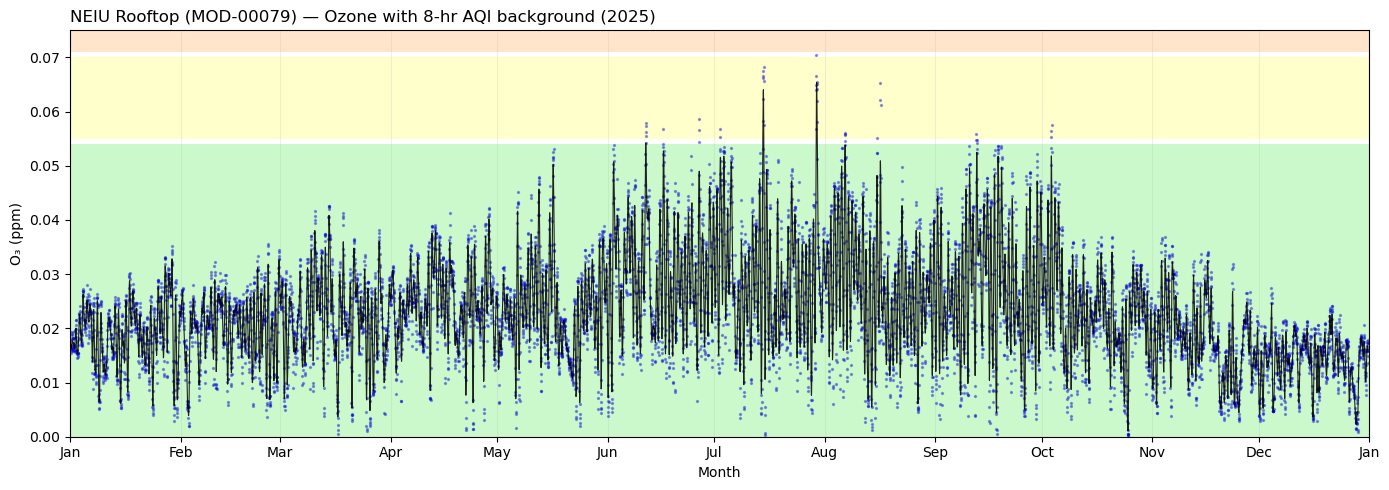

In [18]:
# Annual ozone with the 8-hour AQI background (the AirNow construction).
# AQI o3_8hr categories are defined on the 8-HOUR rolling mean, so we color by
# that (not instantaneous hourly). Ozone is ppb; aqi_boxes / o3_8hr breakpoints
# are ppm, so convert for the band and the rolling-mean overlay only.
o3_ppm = quantaq_hourly["o3"] * PPB_TO_PPM
o3_8hr = o3_ppm.rolling(8, min_periods=6, center=True).mean()
band_max = max(0.075, 1.05 * o3_8hr.max())   # ensure the green/yellow break shows

fig, ax = plt.subplots(figsize=(14, 5))

for box in aqi_boxes("o3_8hr", START_DT, PLOT_END_DT, band_max):
    ax.add_patch(box)

# Raw hourly ozone (ppm) as light dots, 8-hr rolling mean as the line.
ax.plot(quantaq_hourly.index, o3_ppm.to_numpy(),
        linestyle="none", marker="o", markersize=1.4,
        color="mediumblue", alpha=0.35)
ax.plot(o3_8hr.index, o3_8hr.to_numpy(), color="black", linewidth=0.8, alpha=0.85)

ax.set_xlim(START_DT, PLOT_END_DT)
ax.set_ylim(0, band_max)
ax.set_ylabel("O\u2083 (ppm)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("Month")
ax.grid(axis="x", alpha=0.2)
ax.set_title(f"{NEIU_SITE_NAME} \u2014 Ozone with 8-hr AQI background ({YEAR})",
             loc="left")
fig.tight_layout()
save_figure(fig, f"neiu_hourly_ozone_timeseries_{YEAR}.png")
plt.show()


## 2. Time-of-day calendar heatmaps

Hour-of-day (vertical) vs day-of-year (horizontal), one cell per hour. Both
use a **continuous** colormap scaled to the 2nd–98th percentile — *not* AQI
coloring, because rooftop ozone and NO₂ sit entirely in the AQI "Good" band
and AQI coloring would be a flat green field. These run on the **hourly**
series; the heatmap grid is hourly by construction and guards against finer
input. Note the percentile scaling means a few extreme hours saturate at the
top color — read peak values from the timeseries/event panels, not here.


Saved figures/neiu/neiu_ozone_heatmap_2025.png


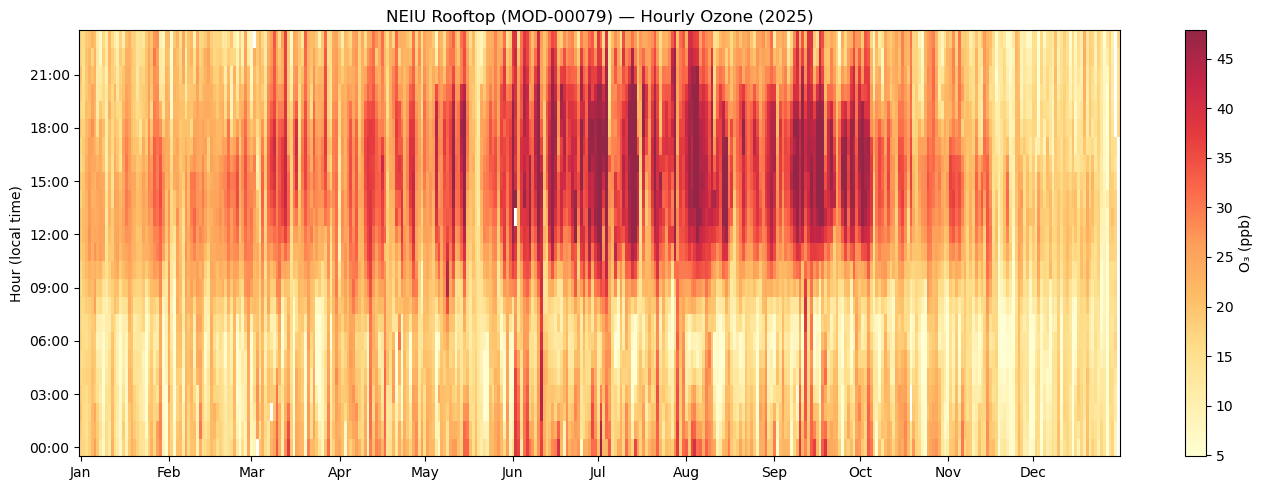

In [19]:
# Continuous colormap (NOT AQI): rooftop ozone sits entirely in the AQI "Good"
# band, so AQI coloring is flat green and hides all structure. Scale to the
# 2nd-98th percentile so a few spikes don't wash out the diurnal pattern.
o3_vmin, o3_vmax = np.nanpercentile(quantaq_hourly["o3"], [2, 98])

fig, ax = plt.subplots(figsize=(14, 5))
hourly_heatmap(
    quantaq_hourly, datetime_col=None, value_col="o3",
    title=f"{NEIU_SITE_NAME} \u2014 Hourly Ozone ({YEAR})",
    colorbar_label="O\u2083 (ppb)",
    cmap="YlOrRd", vmin=o3_vmin, vmax=o3_vmax,
    ax=ax,
)
fig.tight_layout()
save_figure(fig, f"neiu_ozone_heatmap_{YEAR}.png")
plt.show()


Saved figures/neiu/neiu_no2_heatmap_2025.png


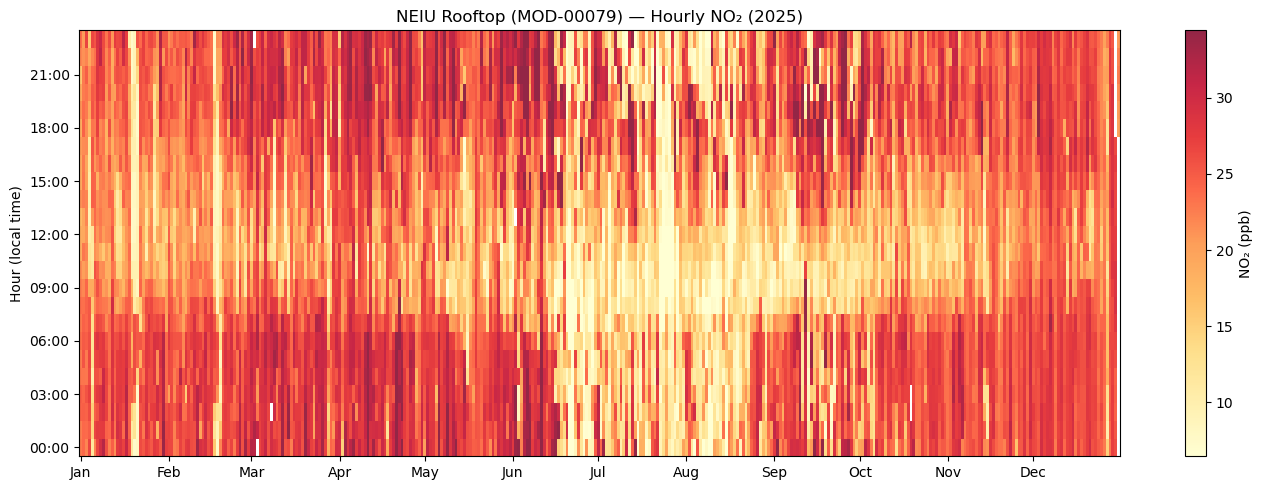

In [20]:
# Continuous colormap (NOT AQI): rooftop NO2 is far below the AQI "Good" ceiling
# (54 ppb), so AQI coloring is flat green. Scale to the 2nd-98th percentile.
no2_vmin, no2_vmax = np.nanpercentile(quantaq_hourly["no2"], [2, 98])

fig, ax = plt.subplots(figsize=(14, 5))
hourly_heatmap(
    quantaq_hourly, datetime_col=None, value_col="no2",
    title=f"{NEIU_SITE_NAME} \u2014 Hourly NO\u2082 ({YEAR})",
    colorbar_label="NO\u2082 (ppb)",
    cmap="YlOrRd", vmin=no2_vmin, vmax=no2_vmax,
    ax=ax,
)
fig.tight_layout()
save_figure(fig, f"neiu_no2_heatmap_{YEAR}.png")
plt.show()


## 3. Wind direction convention check

Confirm `winddir` is **direction FROM** (met standard) before trusting the
roses, by inspecting afternoon winds on the highest-ozone summer days.


In [21]:
daily_max_o3 = (
    paired["o3"].resample("1D").max().dropna().sort_values(ascending=False)
)
top_three_dates = [d.date() for d in daily_max_o3.head(3).index]
print("Top-3 ozone days:", top_three_dates)

afternoon = paired[
    (paired.index.hour >= 13) & (paired.index.hour <= 17)
    & (paired.index.month.isin(range(6, 9)))
]["wdir"]
print("\nAfternoon (13-17h, JJA) wind-direction distribution:")
for lo, hi, name in [(45, 135, "E-ish"), (135, 225, "S-ish"),
                     (225, 315, "W-ish"), (315, 360, "N-ish a"),
                     (0, 45, "N-ish b")]:
    frac = ((afternoon >= lo) & (afternoon < hi)).mean() * 100
    print(f"  {name:10s} [{lo:3d}-{hi:3d}): {frac:4.1f}%")

for day in top_three_dates:
    hour = paired.index.hour
    block = paired[(paired.index.date == day) & (hour >= 12) & (hour <= 18)]
    # Hourly-mean direction for a readable summary of the 5-min data.
    hourly_dir = block["wdir"].resample("1h").mean().round()
    print(f"\n{day} midday wind dir (deg FROM if standard):")
    print(hourly_dir.to_string())


Top-3 ozone days: [datetime.date(2025, 7, 29), datetime.date(2025, 7, 14), datetime.date(2025, 8, 16)]

Afternoon (13-17h, JJA) wind-direction distribution:
  E-ish      [ 45-135): 34.5%
  S-ish      [135-225): 25.1%
  W-ish      [225-315): 15.8%
  N-ish a    [315-360):  4.5%
  N-ish b    [  0- 45): 20.2%

2025-07-29 midday wind dir (deg FROM if standard):
datetime_local
2025-07-29 12:00:00    224.0
2025-07-29 13:00:00    218.0
2025-07-29 14:00:00    248.0
2025-07-29 15:00:00    152.0
2025-07-29 16:00:00     75.0
2025-07-29 17:00:00     79.0
2025-07-29 18:00:00     81.0
Freq: h

2025-07-14 midday wind dir (deg FROM if standard):
datetime_local
2025-07-14 12:00:00     98.0
2025-07-14 13:00:00    104.0
2025-07-14 14:00:00     95.0
2025-07-14 15:00:00     77.0
2025-07-14 16:00:00     73.0
2025-07-14 17:00:00     94.0
2025-07-14 18:00:00     83.0
Freq: h

2025-08-16 midday wind dir (deg FROM if standard):
datetime_local
2025-08-16 12:00:00    266.0
2025-08-16 13:00:00    270.0
2025-08-16 1

## 4. High-ozone event panels

Three columns = the three highest-ozone days. Rows: ozone+NO₂, wind direction
(dot size = speed), solar+temperature. All at 5-min resolution with **raw dots
plus a rolling-mean line** (window = `ROLL_WINDOW` samples ≈ 1 hour), so the
electrochemical scatter is shown honestly while the trend stays legible.
Nighttime shading uses NEIU's own coordinates (derived from the QuantAQ file).


Saved figures/neiu/neiu_lake_breeze_events_2025.png


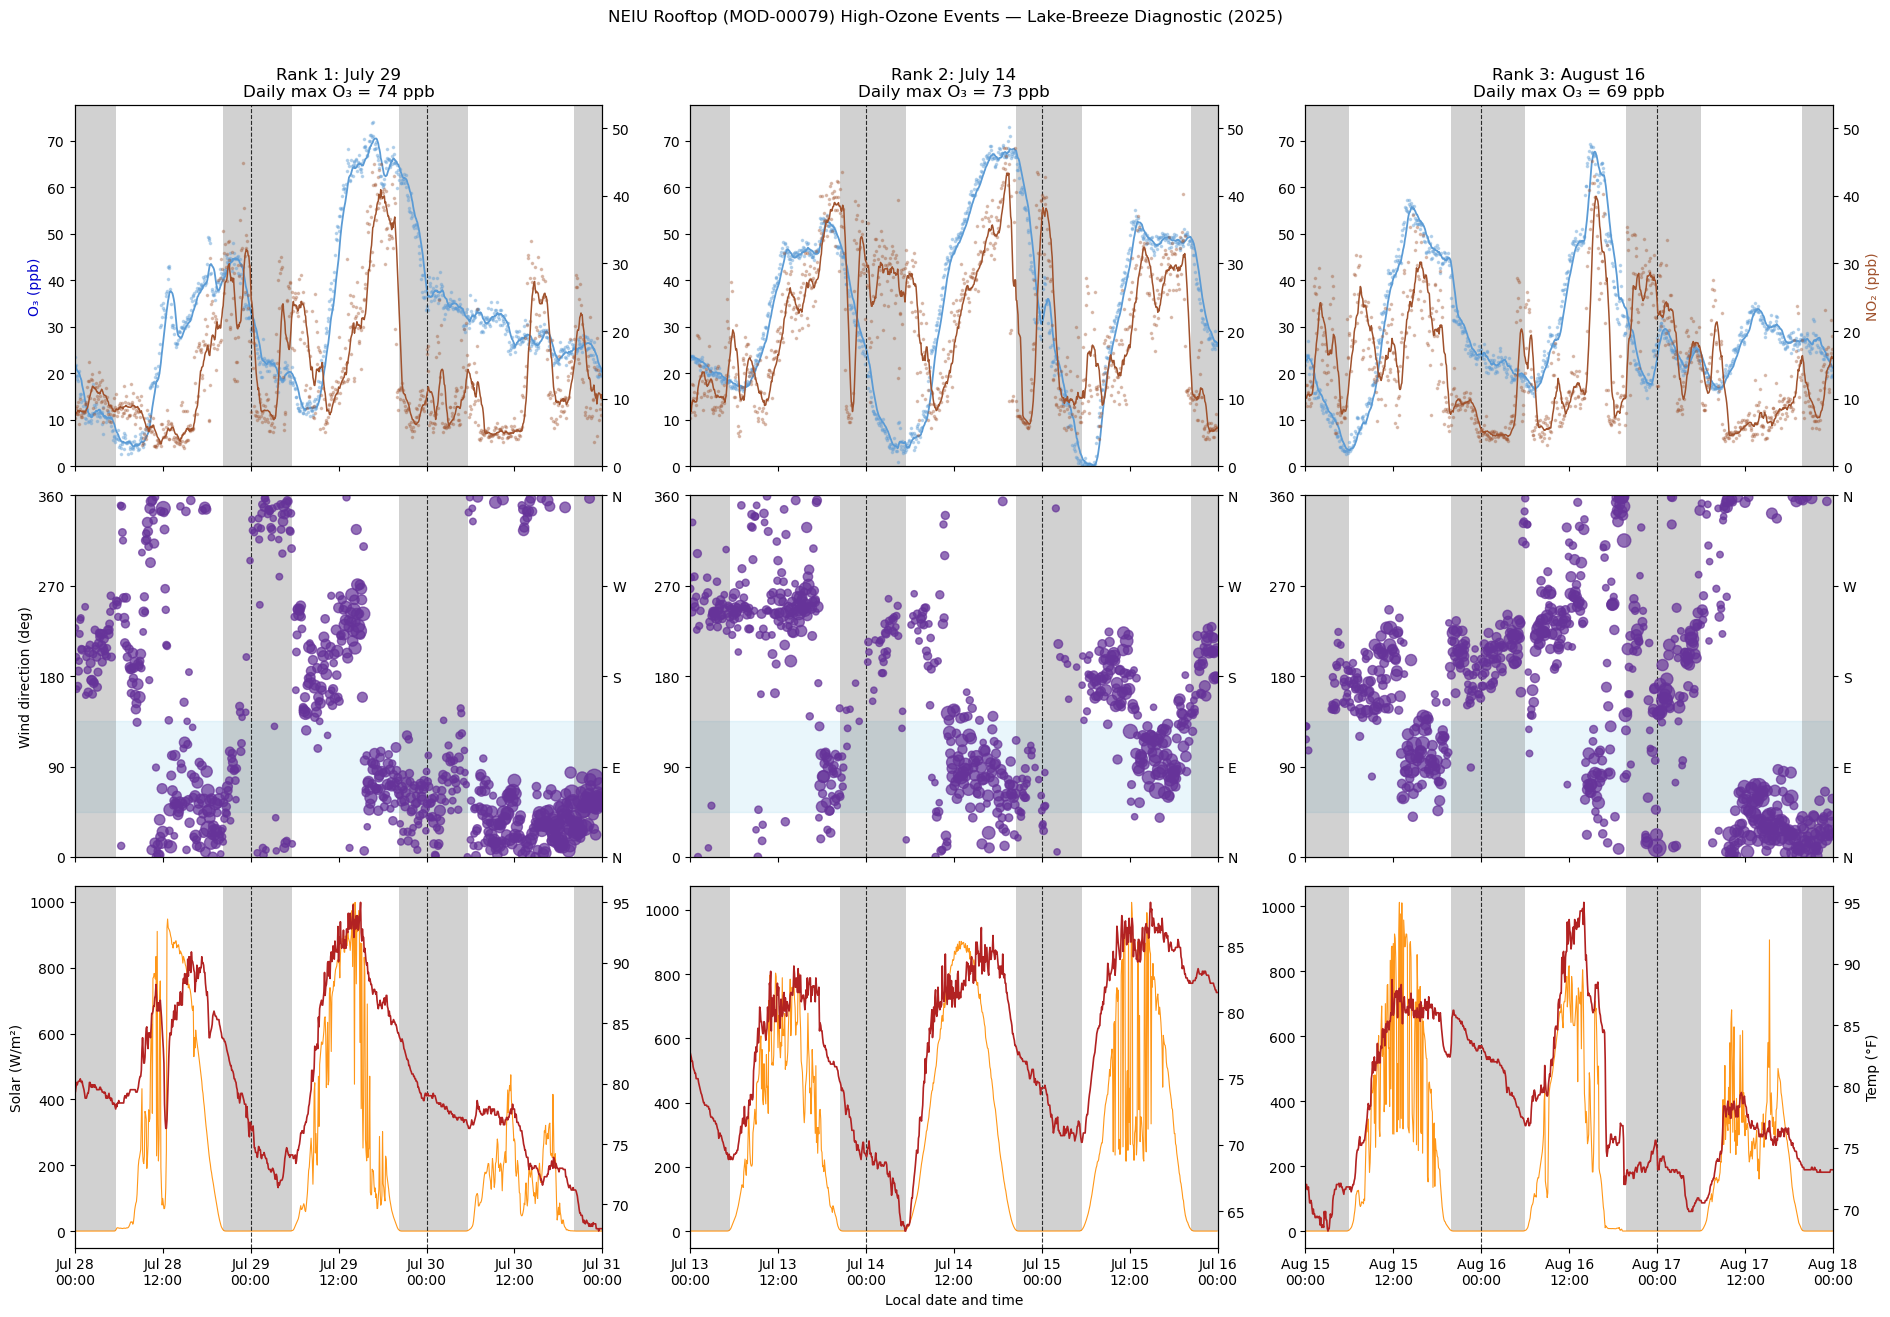

In [22]:
SIZE_FLOOR, SIZE_GAIN = 12, 9   # wind dot area = FLOOR + GAIN * speed(kn)
NEIU_ONSHORE = (45, 135)        # E sector: lakeward / onshore at NEIU


def nighttime_boxes(start_datetime, end_datetime, y_max, latitude, longitude,
                    alpha=0.30):
    """Rectangle patches covering nighttime periods (local time)."""
    solar_day = dt.timedelta(days=1)
    n_days = (end_datetime - start_datetime).days
    sun = Sun(latitude, longitude)
    sunrise = [None] * (n_days + 1)
    sunset = [None] * (n_days + 1)
    for d in range(n_days + 1):
        day = start_datetime + d * solar_day
        sunrise[d] = sun.get_sunrise_time(day).astimezone(CHICAGO_TIME).replace(tzinfo=None)
        sunset[d] = sun.get_sunset_time(day + solar_day).astimezone(CHICAGO_TIME).replace(tzinfo=None)
    boxes = [Rectangle((start_datetime, 0), sunrise[0] - start_datetime, y_max,
                       facecolor="dimgray", alpha=alpha)]
    for d in range(n_days):
        boxes.append(Rectangle((sunset[d], 0), sunrise[d + 1] - sunset[d], y_max,
                               facecolor="dimgray", alpha=alpha))
    return boxes


def event_window(peak_date):
    """Day before through day after a peak date (half-open)."""
    peak_day_start = pd.Timestamp(peak_date).normalize()
    return (peak_day_start - pd.Timedelta(days=1),
            peak_day_start,
            peak_day_start + pd.Timedelta(days=2))


def win(frame, a, b):
    return frame[(frame.index >= a) & (frame.index < b)]


event_o3_max = 1.05 * paired["o3"].max()
event_no2_max = 1.05 * paired["no2"].max()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(19, 13), sharex="col")

for col, peak_date in enumerate(top_three_dates):
    w0, peak_start, w1 = event_window(peak_date)
    peak_end = peak_start + pd.Timedelta(days=1)
    block = win(paired, w0, w1)

    ax_o3, ax_wind, ax_rad = axes[0, col], axes[1, col], axes[2, col]

    # Row 1: ozone + NO2 (raw dots + rolling mean).
    ax_no2 = ax_o3.twinx()
    ax_o3.plot(block.index, block["o3"], "o", ms=1.6, color=OZONE_COLOR, alpha=0.35)
    ax_o3.plot(block.index, block["o3"].rolling(ROLL_WINDOW, min_periods=3).mean(),
               color=OZONE_COLOR, lw=1.3)
    ax_no2.plot(block.index, block["no2"], "o", ms=1.6, color=NO2_COLOR, alpha=0.30)
    ax_no2.plot(block.index, block["no2"].rolling(ROLL_WINDOW, min_periods=3).mean(),
                color=NO2_COLOR, lw=1.1)
    ax_o3.set_ylim(0, event_o3_max)
    ax_no2.set_ylim(0, event_no2_max)
    if col == 0:
        ax_o3.set_ylabel(f"O₃ ({O3_UNITS})", color="mediumblue")
    if col == 2:
        ax_no2.set_ylabel(f"NO₂ ({NO2_UNITS})", color=NO2_COLOR)

    # Row 2: wind direction, dot size = speed.
    # Drop the vane fill value (exactly 180 deg) from THIS scatter only, so the
    # artifact line doesn't appear even where it survived the loader's calm cut.
    wind_block = block[~np.isclose(block["wdir"], 180.0, atol=0.5)]
    sizes = SIZE_FLOOR + SIZE_GAIN * wind_block["wspd"].fillna(0).to_numpy()
    ax_wind.axhspan(*NEIU_ONSHORE, color="skyblue", alpha=0.18, zorder=0)
    ax_wind.scatter(wind_block.index, wind_block["wdir"], s=sizes,
                    color="rebeccapurple", alpha=0.7, zorder=3)
    ax_wind.set_ylim(0, 360)
    ax_wind.set_yticks([0, 90, 180, 270, 360])
    if col == 0:
        ax_wind.set_ylabel("Wind direction (deg)")
    ax_wind_r = ax_wind.twinx()
    ax_wind_r.set_ylim(0, 360)
    ax_wind_r.set_yticks([0, 90, 180, 270, 360])
    ax_wind_r.set_yticklabels(["N", "E", "S", "W", "N"])

    # Row 3: solar (left) + temperature (right).
    ax_temp = ax_rad.twinx()
    ax_rad.plot(block.index, block["solarradiation"], color="darkorange",
                lw=0.8, alpha=0.9, label="Solar")
    ax_temp.plot(block.index, block["tempf"], color="firebrick", lw=1.2, label="Temp")
    if col == 0:
        ax_rad.set_ylabel("Solar (W/m²)")
    if col == 2:
        ax_temp.set_ylabel("Temp (°F)")

    # Shared decoration.
    for ax in (ax_o3, ax_wind, ax_rad):
        for box in nighttime_boxes(w0.to_pydatetime(), w1.to_pydatetime(),
                                   ax.get_ylim()[1], NEIU_LAT, NEIU_LON):
            ax.add_patch(box)
        ax.axvline(peak_start, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.axvline(peak_end, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.set_xlim(w0, w1)

    ax_rad.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax_rad.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax_o3.set_title(f"Rank {col + 1}: {peak_date:%B %d}\n"
                    f"Daily max O₃ = {daily_max_o3.iloc[col]:.0f} {O3_UNITS}")

axes[2, 1].set_xlabel("Local date and time")
fig.suptitle(f"{NEIU_SITE_NAME} High-Ozone Events — Lake-Breeze Diagnostic ({YEAR})",
             y=1.01)
fig.tight_layout()
save_figure(fig, f"neiu_lake_breeze_events_{YEAR}.png")
plt.show()


## 5. Wind roses

Same machinery as the AQS notebook (`dark = HIGH` everywhere). Ozone bins are
the AQS ppm edges ×1000 (ppb). Roses use the 5-min ozone-season frame.


In [23]:
import sys
!{sys.executable} -m pip install --quiet windrose --break-system-packages
from windrose import WindroseAxes

WIND_CMAP = plt.cm.viridis_r
OZONE_CMAP = plt.cm.YlGnBu
NO2_CMAP = plt.cm.YlOrRd

NSECTOR = 16
# CALM_LIMIT_KN defined in the configuration cell above.
WIND_SPEED_BINS = [2, 4, 8, 12, 16]     # knots
OZONE_ROSE_BINS = [0, 25, 40, 55, 70]   # ppb (AQS ppm edges x1000)
NO2_ROSE_BINS = [0, 5, 10, 20, 30]      # ppb


Saved figures/neiu/neiu_wind_rose_timeofday_2025.png


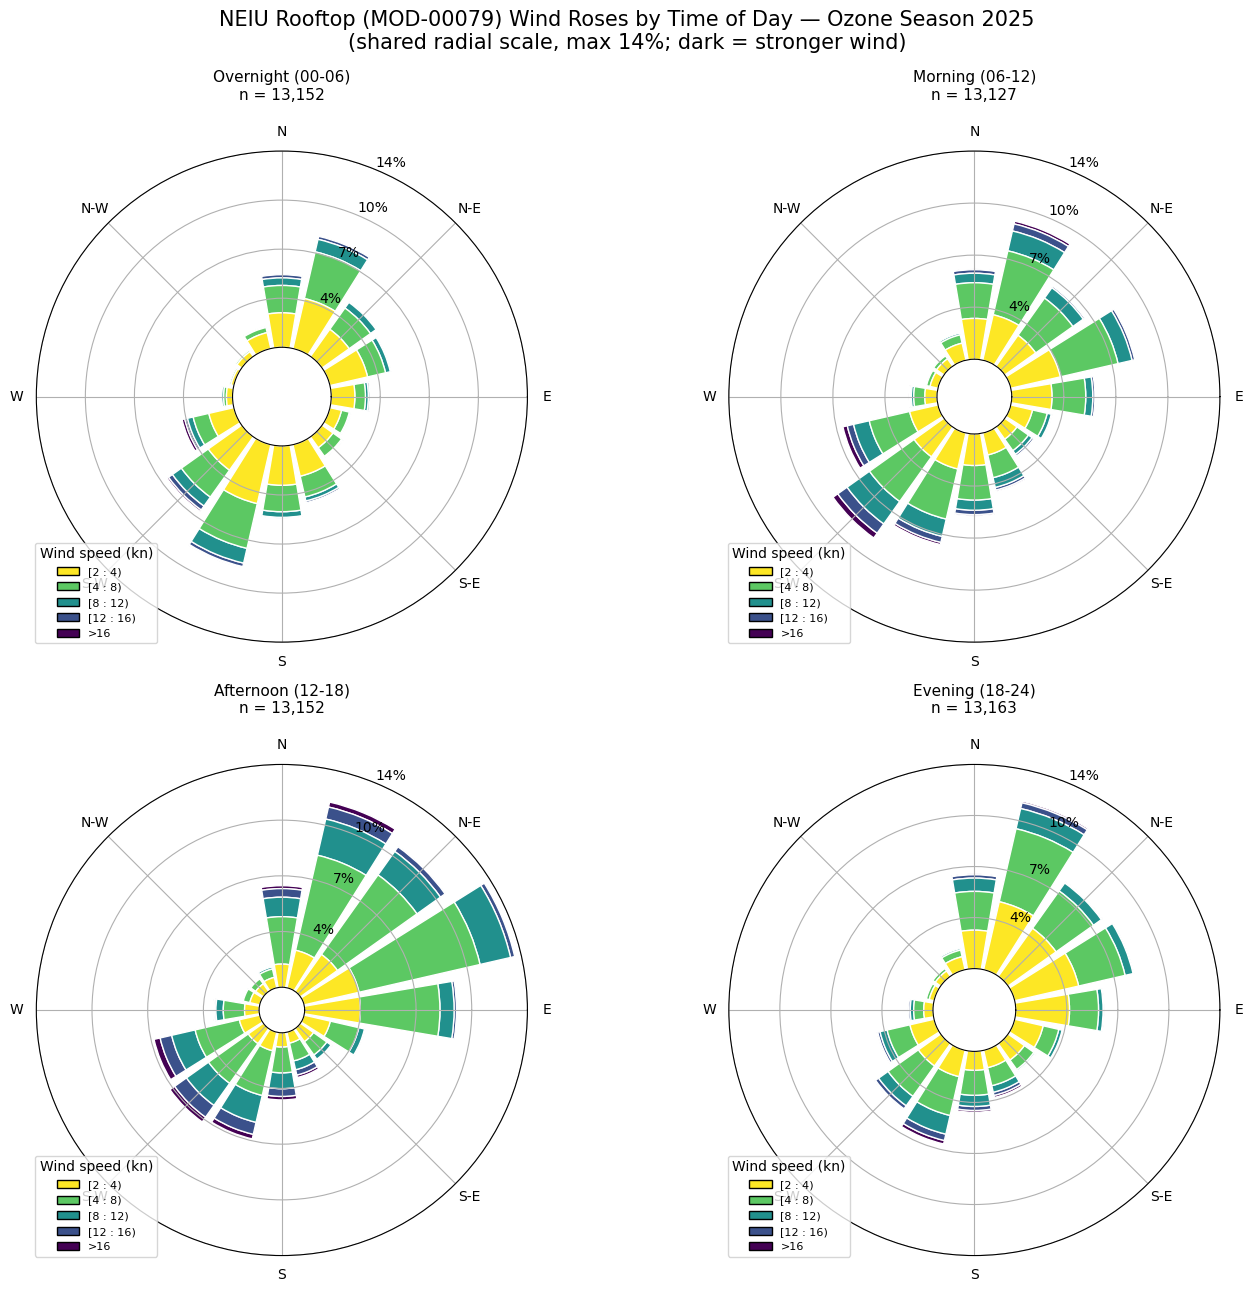

In [24]:
TIME_OF_DAY = {
    "Overnight (00-06)": range(0, 6),
    "Morning (06-12)": range(6, 12),
    "Afternoon (12-18)": range(12, 18),
    "Evening (18-24)": range(18, 24),
}

fig = plt.figure(figsize=(14, 13))
rose_axes, panel_peaks = [], []
for i, (label, hours) in enumerate(TIME_OF_DAY.items(), start=1):
    period = ozone_season[ozone_season.index.hour.isin(hours)].dropna(subset=["wspd"])
    ax = fig.add_subplot(2, 2, i, projection="windrose")
    ax.bar(period["wdir"].to_numpy(), period["wspd"].to_numpy(),
           bins=WIND_SPEED_BINS, nsector=NSECTOR, normed=True,
           opening=0.85, edgecolor="white", cmap=WIND_CMAP, calm_limit=CALM_LIMIT_KN)
    panel_peaks.append(ax._info["table"].sum(axis=0).max())
    ax.set_title(f"{label}\nn = {len(period):,}", fontsize=11, pad=18)
    ax.set_legend(title="Wind speed (kn)", loc="lower left", fontsize=8, decimal_places=0)
    rose_axes.append(ax)

tod_rmax = np.ceil(max(panel_peaks) / 2.0) * 2.0
tod_yticks = list(np.linspace(0, tod_rmax, 5))[1:]
for ax in rose_axes:
    ax.set_rmax(tod_rmax)
    ax.set_rgrids(tod_yticks, labels=[f"{t:.0f}%" for t in tod_yticks])

fig.suptitle(f"{NEIU_SITE_NAME} Wind Roses by Time of Day — Ozone Season {YEAR}\n"
             f"(shared radial scale, max {tod_rmax:.0f}%; dark = stronger wind)",
             fontsize=15, y=0.99)
fig.tight_layout()
save_figure(fig, f"neiu_wind_rose_timeofday_{YEAR}.png")
plt.show()


Saved figures/neiu/neiu_wind_ozone_no2_roses_2025.png


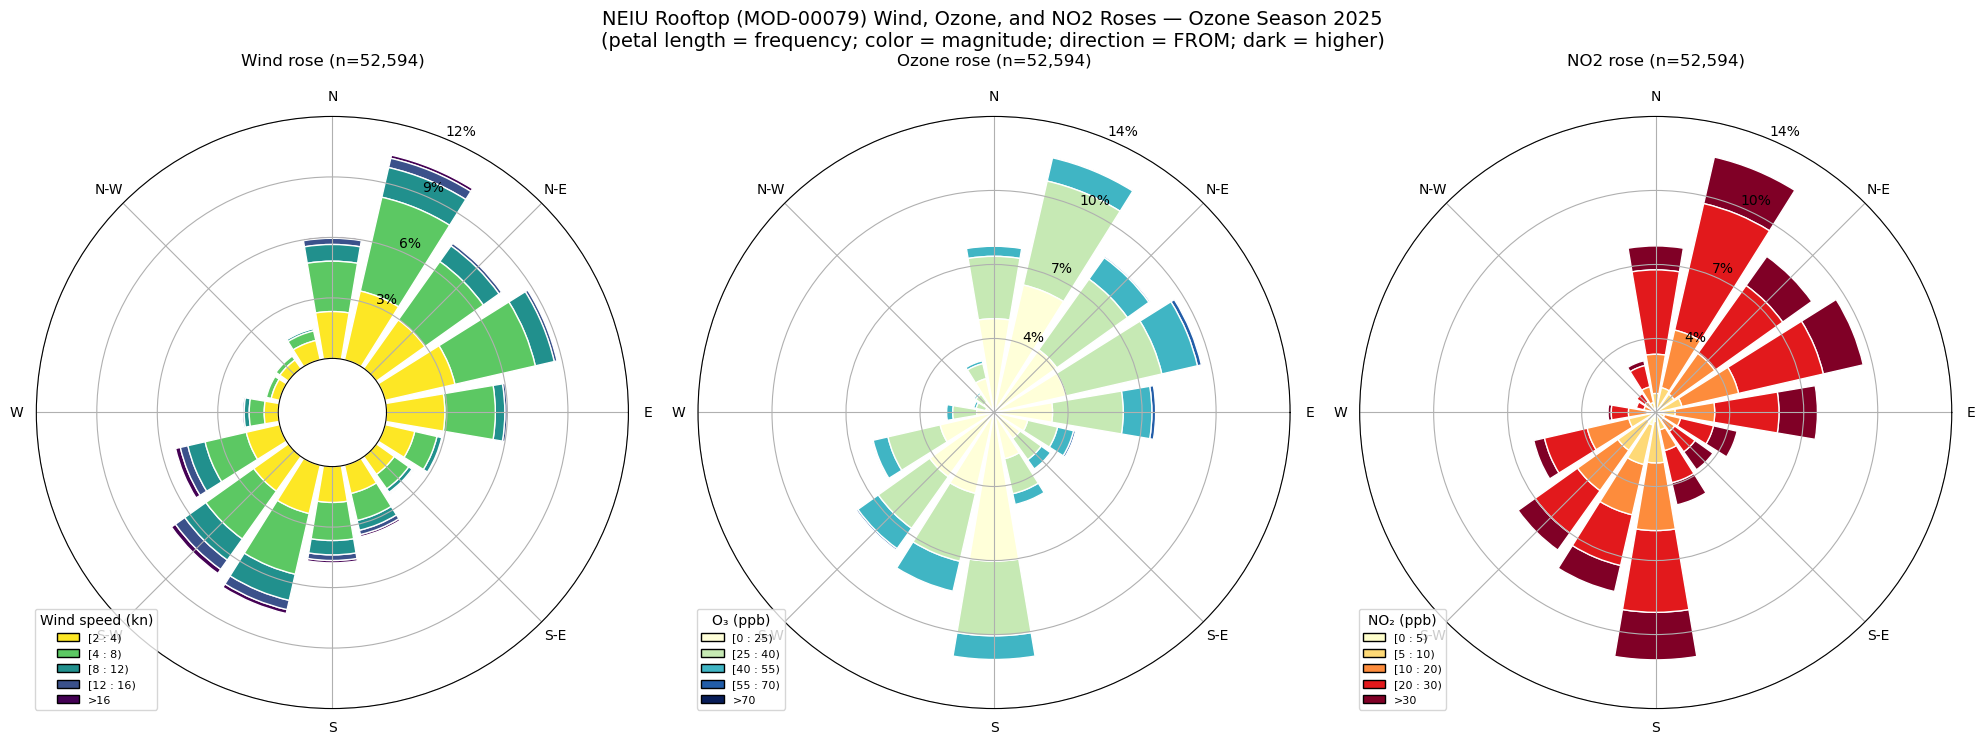

In [25]:
fig = plt.figure(figsize=(20, 7))


def _freq_rose(subplot, dir_vals, var_vals, bins, cmap, title,
               legend_title, decimals, calm=None):
    ax = fig.add_subplot(1, 3, subplot, projection="windrose")
    ax.bar(dir_vals, var_vals, bins=bins, nsector=NSECTOR, normed=True,
           opening=0.85, edgecolor="white", cmap=cmap, calm_limit=calm)
    peak = ax._info["table"].sum(axis=0).max()
    rmax = np.ceil(peak / 2.0) * 2.0
    yticks = list(np.linspace(0, rmax, 5))[1:]
    ax.set_rmax(rmax)
    ax.set_rgrids(yticks, labels=[f"{t:.0f}%" for t in yticks])
    ax.set_title(title, fontsize=12, pad=18)
    ax.set_legend(title=legend_title, loc="lower left", fontsize=8, decimal_places=decimals)
    return ax


wind_ok = ozone_season.dropna(subset=["wspd"])
_freq_rose(1, wind_ok["wdir"].to_numpy(), wind_ok["wspd"].to_numpy(),
           WIND_SPEED_BINS, WIND_CMAP, f"Wind rose (n={len(wind_ok):,})",
           "Wind speed (kn)", 0, calm=CALM_LIMIT_KN)
o3_ok = ozone_season.dropna(subset=["o3"])
_freq_rose(2, o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
           OZONE_ROSE_BINS, OZONE_CMAP, f"Ozone rose (n={len(o3_ok):,})",
           f"O₃ ({O3_UNITS})", 0)
no2_ok = ozone_season.dropna(subset=["no2"])
_freq_rose(3, no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
           NO2_ROSE_BINS, NO2_CMAP, f"NO2 rose (n={len(no2_ok):,})",
           f"NO₂ ({NO2_UNITS})", 0)

fig.suptitle(f"{NEIU_SITE_NAME} Wind, Ozone, and NO2 Roses — Ozone Season {YEAR}\n"
             "(petal length = frequency; color = magnitude; direction = FROM; dark = higher)",
             fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, f"neiu_wind_ozone_no2_roses_{YEAR}.png")
plt.show()


Saved figures/neiu/neiu_mean_concentration_roses_2025.png


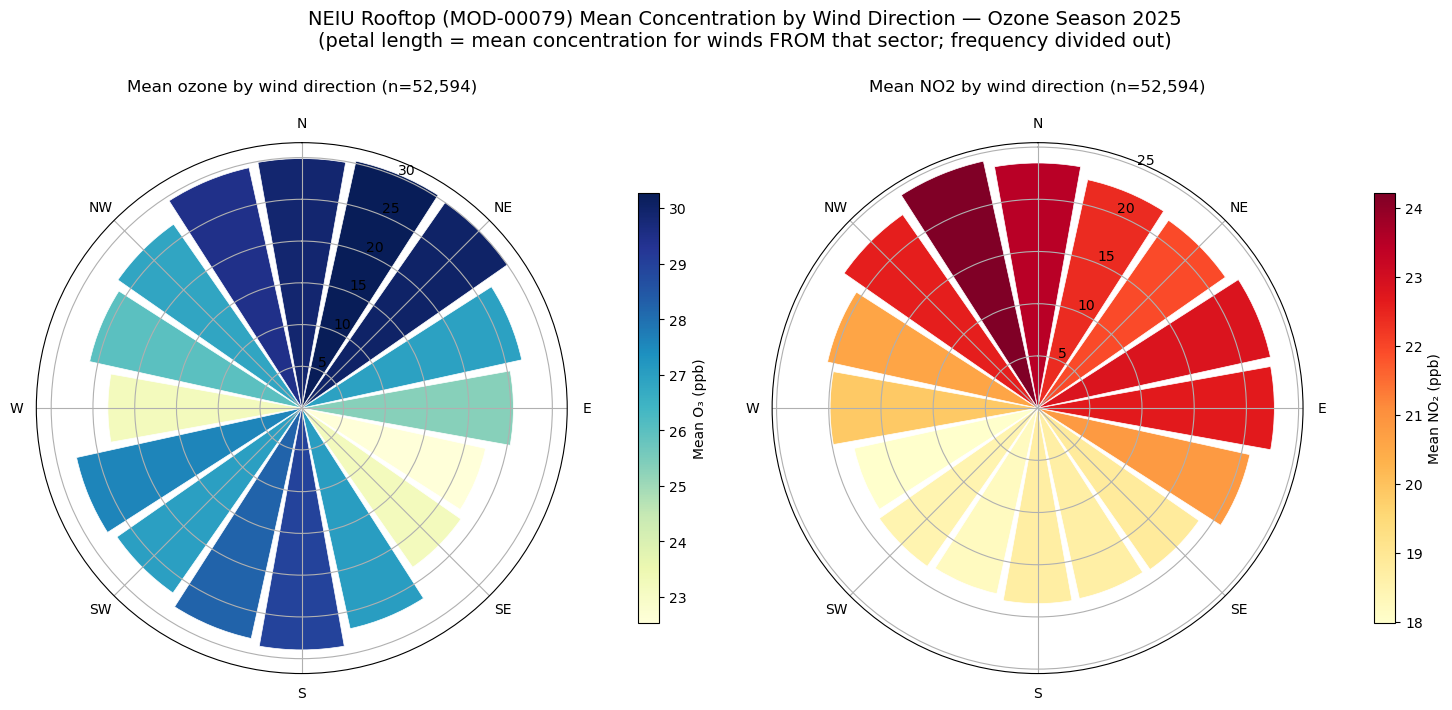

In [26]:
def mean_concentration_rose(ax, wdir, values, cmap, title, cbar_label,
                            nsector=NSECTOR, min_count=5):
    """Polar bar rose: petal length = mean value per direction sector."""
    frame = pd.DataFrame({"wdir": wdir, "val": values}).dropna()
    sector = ((frame["wdir"] % 360) // (360 / nsector)).astype(int)
    grp = frame.groupby(sector)["val"]
    means = grp.mean().reindex(range(nsector))
    counts = grp.count().reindex(range(nsector)).fillna(0)
    means = means.where(counts >= min_count)

    width = 2 * np.pi / nsector
    theta = np.deg2rad(np.arange(nsector) * (360 / nsector))
    theta_plot = (np.pi / 2) - theta
    heights = means.to_numpy()
    norm = plt.Normalize(np.nanmin(heights), np.nanmax(heights))
    colors = cmap(norm(heights))

    ax.bar(theta_plot, np.nan_to_num(heights), width=width * 0.9,
           color=colors, edgecolor="white", linewidth=0.5)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(title, fontsize=12, pad=18)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7).set_label(cbar_label)


fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": "polar"})
o3_ok = ozone_season.dropna(subset=["o3"])
mean_concentration_rose(axes[0], o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
                        OZONE_CMAP, f"Mean ozone by wind direction (n={len(o3_ok):,})",
                        f"Mean O₃ ({O3_UNITS})")
no2_ok = ozone_season.dropna(subset=["no2"])
mean_concentration_rose(axes[1], no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
                        NO2_CMAP, f"Mean NO2 by wind direction (n={len(no2_ok):,})",
                        f"Mean NO₂ ({NO2_UNITS})")
fig.suptitle(f"{NEIU_SITE_NAME} Mean Concentration by Wind Direction — Ozone Season {YEAR}\n"
             "(petal length = mean concentration for winds FROM that sector; frequency divided out)",
             fontsize=14, y=1.03)
fig.tight_layout()
save_figure(fig, f"neiu_mean_concentration_roses_{YEAR}.png")
plt.show()


## Suggested questions

- Does high ozone at NEIU associate with a consistent wind sector, and does it
  match the lakeward direction for this rooftop?
- Is there an afternoon onshore lobe absent in the morning — an aggregate
  lake-breeze signature?
- How does the ozone/NO₂ directional split compare to Northbrook's? NEIU's
  co-located sensors mean **no wind-displacement confound**.
- Do the electrochemical NO₂ patterns differ from AQS chemiluminescence NO₂
  in ways suggesting sensor cross-sensitivity rather than real structure?
